# Exploratory Data Analysis


We have 3 datasets, we quickly go through them and perform basic statistical summaries to get familiar with their structures

## Importing packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

## Data loading

We have 3 datasets, the main one contains information on the effects of drug combinations on different cell lines; the other two provide further details on the cell lines and drugs.

### Drug synergy dataset

This is the main dataset, it contains information on drug combinations applied to a variety of cell lines. We are interested in the 'synergy score', an estimate of how drugs interact with each other:

In [2]:
drug_synergy_df=pd.read_csv('../data/drug_synergy.csv')
print('Drug synergy: ' + str(drug_synergy_df.shape))

drug_synergy_df.head()

Drug synergy: (3879, 16)


,Cell line name,Compound A,Compound B,Max. conc. A,Max. conc. B,IC50 A,H A,Einf A,IC50 B,H B,Einf B,Synergy score,QA,Combination ID,Challenge,Dataset
0,BT-20,AKT,ADAM17,1.0,75.0,1.000000,0.809002,59.122436,9.639714,0.757977,91.593425,29.540390,1,ADAM17.AKT,ch1,train
1,CAL-120,AKT,ADAM17,1.0,75.0,0.183214,2.503678,60.411999,1.000000,0.000000,100.000000,4.401410,-1,ADAM17.AKT,ch1,train
2,CAL-51,AKT,ADAM17,1.0,75.0,1.000000,0.726984,11.150843,75.000000,0.375043,76.656479,0.315422,1,ADAM17.AKT,ch1,train
3,DU-4475,AKT,ADAM17,1.0,75.0,0.321533,10.000000,58.599487,75.000000,1.995866,6.171007,-41.734090,-1,ADAM17.AKT,ch1,train
4,HCC1143,AKT,ADAM17,1.0,75.0,0.398673,10.000000,89.098894,1.000000,0.000000,100.000000,35.532770,-1,ADAM17.AKT,ch1,train


we have close to 4k combinatorial experiments described by the first 3 columns.

We use the function `pd.info()` to learn a bit about the dataset:

In [312]:
drug_synergy_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3879 entries, 0 to 3878
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cell line name  3879 non-null   str    
 1   Compound A      3879 non-null   str    
 2   Compound B      3879 non-null   str    
 3   Max. conc. A    3879 non-null   float64
 4   Max. conc. B    3879 non-null   float64
 5   IC50 A          3879 non-null   float64
 6   H A             3879 non-null   float64
 7   Einf A          3879 non-null   float64
 8   IC50 B          3879 non-null   float64
 9   H B             3879 non-null   float64
 10  Einf B          3879 non-null   float64
 11  Synergy score   3879 non-null   float64
 12  QA              3879 non-null   int64  
 13  Combination ID  3879 non-null   str    
 14  Challenge       3879 non-null   str    
 15  Dataset         3879 non-null   str    
dtypes: float64(9), int64(1), str(6)
memory usage: 485.0 KB


we notice we have no null values and both numerical and categorical features.

Another function for summary statistics is `pd.describe()`:

for the categorical features:

In [313]:
drug_synergy_df.describe( include='str' ) #descriptive stats for string vars

,Cell line name,Compound A,Compound B,Combination ID,Challenge,Dataset
count,3879,3879,3879,3879,3879,3879
unique,85,54,47,169,1,3
top,CAMA-1,PIK3C,AKT,MAP2K_1.PIK3C,ch1,train
freq,107,407,425,60,3879,2199


from and `Combination ID` and `Cell line name` we see that we have 169 experiments, some of them repeated across 85 cell lines. Experiments are determined by the `Compound A` and `Compund B` columns, each having around around 50 unique values. To see how many different drugs are involved we do:

In [314]:
Drugs = list(drug_synergy_df['Compound A']) + list(drug_synergy_df['Compound B'])
DrugsSet = set(Drugs) #sets keep unique elements only

print('We draw combinations from ' + str( len(DrugsSet) ) + ' drugs')

We draw combinations from 69 drugs


### Cell lines dataset

This dataset contains information on cell lines:

In [ ]:
cell_lines_df=pd.read_csv('../data/cell_lines.csv')
print('Cell lines dataset size: ' + str(cell_lines_df.shape))

cell_lines_df.head()

Cell lines dataset size: (159, 10)


,Cell line name,COSMIC ID,GDSC tissue descriptor 1,GDSC tissue descriptor 2,TCGA label,MSI,Growth properties,AZ-DREAM,O'Neil et al. 2016,ALMANAC
0,22RV1,924100,urogenital_system,prostate,PRAD,MSI-H,Adherent,1.0,0.0,0.0
1,647-V,906797,urogenital_system,Bladder,BLCA,MSS/MSI-L,Adherent,1.0,0.0,0.0
2,786-0,905947,kidney,kidney,KIRC,MSS/MSI-L,Adherent,0.0,0.0,1.0
3,A2058,906792,skin,melanoma,SKCM,MSS/MSI-L,Adherent,0.0,1.0,0.0
4,A2780,906804,urogenital_system,ovary,UNABLE TO CLASSIFY,MSS/MSI-L,Semi-Adherent,0.0,1.0,0.0


we apply summary statistics again:

In [316]:
cell_lines_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Cell line name            159 non-null    str    
 1   COSMIC ID                 159 non-null    int64  
 2   GDSC tissue descriptor 1  159 non-null    str    
 3   GDSC tissue descriptor 2  159 non-null    str    
 4   TCGA label                151 non-null    str    
 5   MSI                       158 non-null    str    
 6   Growth properties         159 non-null    str    
 7   AZ-DREAM                  144 non-null    float64
 8   O'Neil et al. 2016        144 non-null    float64
 9   ALMANAC                   144 non-null    float64
dtypes: float64(3), int64(1), str(6)
memory usage: 12.6 KB


this time we do have null values in several columns, and again both numerical and categorical features

In [317]:
cell_lines_df.describe( include='str' ) 

,Cell line name,GDSC tissue descriptor 1,GDSC tissue descriptor 2,TCGA label,MSI,Growth properties
count,159,159,159,151,158,159
unique,144,12,19,18,2,3
top,SW837,breast,breast,BRCA,MSS/MSI-L,Adherent
freq,2,37,37,36,144,142


we have information on 159 cell lines, although not the same info for all of them. Remember that the main dataset contained 85. We leave further exploration until the feature selection section.

### Drug portfolio dataset

This dataset contains information on the drugs. 

To properly read this file, we first need to figure out the separator between values (notice it doesn't render properly on github):

In [ ]:
with open('../data/drug_portfolio.csv') as f:
    lines = [line.rstrip() for line in f.readlines()] #list of lines on f
    
for l in lines[:5]: #print a few, let's see if we notice a pattern
    print(repr(l)) 

'Drug name\tChallenge drug name\tPutative target\tFunction\tPathway\tHBA\tHBD\tMolecular weight\tcLogP\tLipinski\tSMILES'
'MEDI3622\tADAM17\tADAM17\tDifferentiation\tEMT/migration\t-\t-\t-\t-\t-\tAntibody (MEDI3622)'
'AZD5363\tAKT\tAKT1;AKT2;AKT3\tOncogenic signal\tAKT/PI3K\t8\t5\t428.9\t1.18\t0\tc1cc(ccc1[C@H](CCO)NC(=O)C2(CCN(CC2)c3c4cc[nH]c4ncn3)N)Cl'
'MK2206\tAKT_1\tAKT*\tOncogenic signal\tAKT/PI3K\t6\t3\t407.5\t3.24\t0\tc1ccc(cc1)c2cc3c(ccn4c3n[nH]c4=O)nc2c5ccc(cc5)C6(CCC6)N'
'Perifosine,KRX-0401\tAKT_PIK3C\tAKT*;PIK3C*\tOncogenic signal\tAKT/PI3K\tNA\tNA\tNA\tNA\tNA\tNA'


and we see it's `tab`. Then:

In [319]:
drug_portfolio_df=pd.read_csv('data/drug_portfolio.csv', sep='\t')
print('Drug portfolio dataset size: ' + str(drug_portfolio_df.shape))

drug_portfolio_df.head()

Drug portfolio dataset size: (118, 11)


,Drug name,Challenge drug name,Putative target,Function,Pathway,HBA,HBD,Molecular weight,cLogP,Lipinski,SMILES
0,MEDI3622,ADAM17,ADAM17,Differentiation,EMT/migration,-,-,-,-,-,Antibody (MEDI3622)
1,AZD5363,AKT,AKT1;AKT2;AKT3,Oncogenic signal,AKT/PI3K,8,5,428.9,1.18,0,c1cc(ccc1[C@H](CCO)NC(=O)C2(CCN(CC2)c3c4cc[nH]...
2,MK2206,AKT_1,AKT*,Oncogenic signal,AKT/PI3K,6,3,407.5,3.24,0,c1ccc(cc1)c2cc3c(ccn4c3n[nH]c4=O)nc2c5ccc(cc5)...
3,"Perifosine,KRX-0401",AKT_PIK3C,AKT*;PIK3C*,Oncogenic signal,AKT/PI3K,NaN,NaN,NaN,NaN,NaN,NaN
4,"AZ13409007, AKTaz",AKT_SGK,AKT*;SGK*,Oncogenic signal,AKT/PI3K,8,3,459.3,2.25,0,COc1cc2c(cc1OC)C3(CCN(CC3)c4c5c([nH]nc5Br)ncn4...


as before, we do some summary statistics:

In [320]:
drug_portfolio_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Drug name            115 non-null    str  
 1   Challenge drug name  118 non-null    str  
 2   Putative target      118 non-null    str  
 3   Function             118 non-null    str  
 4   Pathway              118 non-null    str  
 5   HBA                  63 non-null     str  
 6   HBD                  63 non-null     str  
 7   Molecular weight     63 non-null     str  
 8   cLogP                63 non-null     str  
 9   Lipinski             63 non-null     str  
 10  SMILES               63 non-null     str  
dtypes: str(11)
memory usage: 10.3 KB


we have a lot of null values here; also, all features are strings.

In [321]:
drug_portfolio_df.describe( include='str' )

,Drug name,Challenge drug name,Putative target,Function,Pathway,HBA,HBD,Molecular weight,cLogP,Lipinski,SMILES
count,115,118,118,118,118,63,63,63,63,63,63
unique,115,118,84,6,13,13,8,59,58,5,63
top,MEDI3622,ADAM17,DNA,Oncogenic signal,AKT/PI3K,7,1,412.5,4.29,0,Antibody (MEDI3622)
freq,1,1,6,59,22,15,18,2,3,42,1


so we have information on 115 drugs, although not the same info on all. Remember the main dataset contained combinations of 69 different drugs.

## Conclusions
* We have close to 4k experiments
* Experiments consist of 169 paired combinations of 69 drugs, across 85 cell lines (non comprehensive)
* We have (incomplete) information on 115 drugs and 159 cell lines, so we will require filtering

## Quality control and feature engineering

### Feature selection

We follow the feature selection criteria of the original paper. Some of the features and experiments are dropped according to:

* Keep only experiments with high quality, `QA == 1 `
* Remove features with over 20% missing values: `HBA`, `HBD`, `Molecular weight`, `cLogP`, `Lipinski`, `SMILES`
* Remove 'unnercesary or redundant' columns. According to the study, these are: `Challenge`, `QA`, `COSMIC ID`, `GDSC tissue descriptor 1`, `TCGA`, `Dataset`, `Combination ID`

Then:

In [322]:
#Quality filtering
drug_synergy_df = drug_synergy_df[drug_synergy_df.QA==1]

print('Drug synergy: ' + str(drug_synergy_df.shape))
drug_synergy_df.head()

Drug synergy: (3475, 16)


,Cell line name,Compound A,Compound B,Max. conc. A,Max. conc. B,IC50 A,H A,Einf A,IC50 B,H B,Einf B,Synergy score,QA,Combination ID,Challenge,Dataset
0,BT-20,AKT,ADAM17,1.0,75.0,1.000000,0.809002,59.122436,9.639714,0.757977,91.593425,29.540390,1,ADAM17.AKT,ch1,train
2,CAL-51,AKT,ADAM17,1.0,75.0,1.000000,0.726984,11.150843,75.000000,0.375043,76.656479,0.315422,1,ADAM17.AKT,ch1,train
5,HCC1187,AKT,ADAM17,1.0,75.0,0.410029,1.496901,51.921265,1.000000,0.000000,100.000000,-0.801993,1,ADAM17.AKT,ch1,train
7,HCC1806,AKT,ADAM17,1.0,75.0,0.313992,10.000000,63.399635,75.000000,0.392570,48.650054,-26.733250,1,ADAM17.AKT,ch1,train
8,HCC1937,AKT,ADAM17,1.0,75.0,1.000000,0.771830,41.529554,1.677924,1.119487,92.188029,32.165520,1,ADAM17.AKT,ch1,train


In [323]:
#missing vals fitlering
drug_synergy_bool = (drug_synergy_df.isna().sum() < len(drug_synergy_df)*0.2).values #logical vector, T if less than 20% missing values
cell_lines_df_bool = (cell_lines_df.isna().sum() < len(cell_lines_df)*0.2).values
drug_portfolio_df_bool = (drug_portfolio_df.isna().sum() < len(drug_portfolio_df)*0.2).values

drug_synergy_df = drug_synergy_df[ drug_synergy_df.columns[drug_synergy_bool] ]
cell_lines_df = cell_lines_df[ cell_lines_df.columns[cell_lines_df_bool] ]
drug_portfolio_df = drug_portfolio_df[ drug_portfolio_df.columns[drug_portfolio_df_bool] ]

print('Drug portfolio: ' + str(drug_portfolio_df.shape))
drug_portfolio_df.head()

Drug portfolio: (118, 5)


,Drug name,Challenge drug name,Putative target,Function,Pathway
0,MEDI3622,ADAM17,ADAM17,Differentiation,EMT/migration
1,AZD5363,AKT,AKT1;AKT2;AKT3,Oncogenic signal,AKT/PI3K
2,MK2206,AKT_1,AKT*,Oncogenic signal,AKT/PI3K
3,"Perifosine,KRX-0401",AKT_PIK3C,AKT*;PIK3C*,Oncogenic signal,AKT/PI3K
4,"AZ13409007, AKTaz",AKT_SGK,AKT*;SGK*,Oncogenic signal,AKT/PI3K


In [324]:
#irrelevant features filtering
badfeats = ['Challenge', 'QA', 'COSMIC ID', 'GDSC tissue descriptor 1', 'TCGA','Dataset','Combination ID']

#filter irrelevant or redundant features
def filterfunc( df ):
    ''' Takes a df and checks its cols, if they in badfeats, they are removed '''
    tobedropped = []
    for col in df.columns:
        if col in badfeats:
            tobedropped.append(col)
    
    df = df.drop( tobedropped, axis=1 )
    return df

drug_synergy_df = filterfunc(drug_synergy_df)
cell_lines_df = filterfunc(cell_lines_df)
drug_portfolio_df = filterfunc(drug_portfolio_df)

print( 'Final features: \n' )
print( 'Drug combinations: ', drug_synergy_df.columns )
print( 'Cell lines: ', cell_lines_df.columns)
print( 'Drug portfolio: ', drug_portfolio_df.columns)

Final features: 

Drug combinations:  Index(['Cell line name', 'Compound A', 'Compound B', 'Max. conc. A',
       'Max. conc. B', 'IC50 A', 'H A', 'Einf A', 'IC50 B', 'H B', 'Einf B',
       'Synergy score'],
      dtype='str')
Cell lines:  Index(['Cell line name', 'GDSC tissue descriptor 2', 'TCGA label', 'MSI',
       'Growth properties', 'AZ-DREAM ', 'O'Neil et al. 2016', 'ALMANAC'],
      dtype='str')
Drug portfolio:  Index(['Drug name', 'Challenge drug name', 'Putative target', 'Function',
       'Pathway'],
      dtype='str')


We continue following the paper. We integrate information from `cell_lines_df` and from `drug_portfolio_df` into the drug combinations dataset:

* From the cell lines df: `GDSC tissue descriptor 2`, `MSI`, `Growth properties`.
* From the drug portfolio df: `Putative target`, `Function`, `Pathway`, for each drug. Notice, this means we need 6 columns in total, 3 for `Compound A` and 3 for `Compund B`

In [325]:
#cell line, drugA and drug B dfs
cell_lines_df = cell_lines_df[ ['Cell line name', 'GDSC tissue descriptor 2', 'MSI', 'Growth properties'] ]
cell_lines_df.drop_duplicates( inplace=True ) #as we removed some columns, we might have duplicate rows

drug_portfolio_df_A = drug_portfolio_df[ ['Challenge drug name', 'Putative target','Function', 'Pathway'] ]
drug_portfolio_df_A.columns = ['Compound A', 'Putative target A','Function A', 'Pathway A'] #rename (notice we use 'Challenge drug name' and not 'Drug name')
drug_portfolio_df_A.drop_duplicates( inplace=True )

drug_portfolio_df_B = drug_portfolio_df[ ['Challenge drug name', 'Putative target','Function', 'Pathway'] ]
drug_portfolio_df_B.columns = ['Compound B', 'Putative target B','Function B', 'Pathway B'] #rename
drug_portfolio_df_B.drop_duplicates( inplace=True )

#join on drug combination df
df = pd.merge( drug_synergy_df, cell_lines_df, on='Cell line name' ) #create df and add cell line info
df = pd.merge( df, drug_portfolio_df_A, on='Compound A' ) #add drug A info
df = pd.merge( df, drug_portfolio_df_B, on='Compound B' ) #add drug B info

print( 'Drug synergy related features:' )
print(*drug_synergy_df.columns, sep=", ")
print( '-----------------------------------------------------------------------------------------------------------------' )

print( 'Cell line related features:' )
print(*cell_lines_df.columns, sep=", ")
print( '-----------------------------------------------------------------------------------------------------------------' )


print( 'Drug related features:' )
print(*drug_portfolio_df_A.columns, sep=", ")
print( '-----------------------------------------------------------------------------------------------------------------' )

print('\n' )
print( 'Final dataframe:' + str(df.shape) )
df.head()

Drug synergy related features:
Cell line name, Compound A, Compound B, Max. conc. A, Max. conc. B, IC50 A, H A, Einf A, IC50 B, H B, Einf B, Synergy score
-----------------------------------------------------------------------------------------------------------------
Cell line related features:
Cell line name, GDSC tissue descriptor 2, MSI, Growth properties
-----------------------------------------------------------------------------------------------------------------
Drug related features:
Compound A, Putative target A, Function A, Pathway A
-----------------------------------------------------------------------------------------------------------------


Final dataframe:(3475, 21)


,Cell line name,Compound A,Compound B,Max. conc. A,Max. conc. B,IC50 A,H A,Einf A,IC50 B,H B,...,Synergy score,GDSC tissue descriptor 2,MSI,Growth properties,Putative target A,Function A,Pathway A,Putative target B,Function B,Pathway B
0,BT-20,AKT,ADAM17,1.0,75.0,1.000000,0.809002,59.122436,9.639714,0.757977,...,29.540390,breast,MSS/MSI-L,Adherent,AKT1;AKT2;AKT3,Oncogenic signal,AKT/PI3K,ADAM17,Differentiation,EMT/migration
1,CAL-51,AKT,ADAM17,1.0,75.0,1.000000,0.726984,11.150843,75.000000,0.375043,...,0.315422,breast,MSS/MSI-L,Adherent,AKT1;AKT2;AKT3,Oncogenic signal,AKT/PI3K,ADAM17,Differentiation,EMT/migration
2,HCC1187,AKT,ADAM17,1.0,75.0,0.410029,1.496901,51.921265,1.000000,0.000000,...,-0.801993,breast,MSS/MSI-L,Suspension,AKT1;AKT2;AKT3,Oncogenic signal,AKT/PI3K,ADAM17,Differentiation,EMT/migration
3,HCC1806,AKT,ADAM17,1.0,75.0,0.313992,10.000000,63.399635,75.000000,0.392570,...,-26.733250,breast,MSS/MSI-L,Adherent,AKT1;AKT2;AKT3,Oncogenic signal,AKT/PI3K,ADAM17,Differentiation,EMT/migration
4,HCC1937,AKT,ADAM17,1.0,75.0,1.000000,0.771830,41.529554,1.677924,1.119487,...,32.165520,breast,MSS/MSI-L,Adherent,AKT1;AKT2;AKT3,Oncogenic signal,AKT/PI3K,ADAM17,Differentiation,EMT/migration


### Features description

This is a study on drug synergy in cancer cells. Drugs are inhibitors, and the measured effect is *cell viability* (the percentage of cells survigin treatment). The final dataset contains 8 categorical and 13 numerical features:

* Cell line name: 85 unique cancer cell lines (categorical)
* Compound A/B: 69 unique drugs (categorical)
* Max. conc. A/B: highest dose tested in the experiment (numerical)
* IC50 A/B: concentration required to reach half inhibition; a measure of drug's potency (numerical)
* Einf A/B: maximal effect (lowest viability) achieved at infinite concentration; a measure of drug efficacy  (numerical)
* H A/B: Hill coefficient; describes the steepness of the drug dose-response curve. $H>1$ indicates a sharp switch like response, $H<1$ a very slow one (numerical)
* Synergy score: a measure of interaction, postive values mean the drugs enhance each other (synergy), zero is additivity and negative is antagonism (numerical)
* GDSC tissue descriptor 2: organ / tissue origin of the cancer; tags from the Genomics of Drug Sensitivity in Cancer database (categorical)
* MSI: microsatielite instability status, indicates if DNA repair is broken; 'high' status often increases drug sensitivty (categorical)
* Growth properties: how cells grow in lab; shape and tendency to stick to their neighbors can affect drug efficacy (categorical)
* Putative target A / B: drug target (categorical)
* Function A/B: functional annotation of the drug, what it does to the target (categorical)
* Pathway A/B: drug biological pathway (categorical)


## Visualization

We finalize this notebook by visually exploring some of the relationships between the dataset's features, particularly their relation to the `Synergy score`.

### Variable distributions

We firstly inspect the distributions of all variables, numerical and categorical:

In [326]:
#num and cat subdfs
numdf = df.select_dtypes( include='number' )
catdf = df.select_dtypes( include='string' )

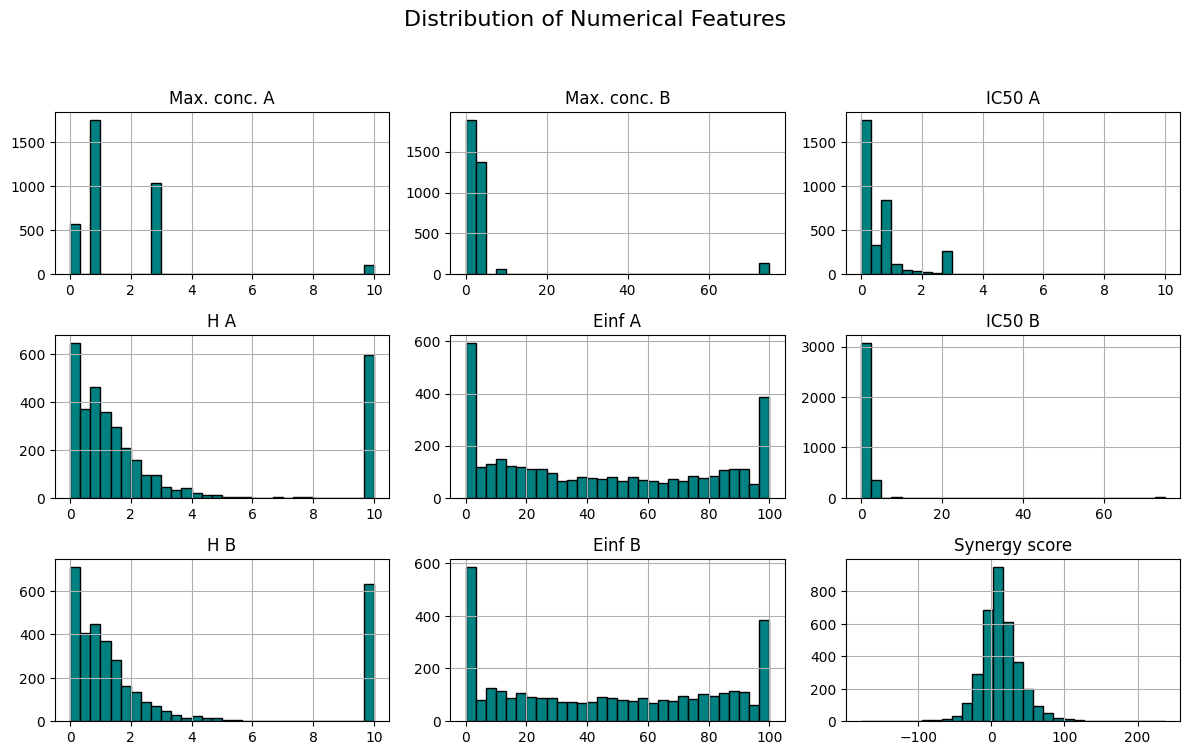

In [327]:
#num vars distribs
numdf.hist(bins=30, figsize=(12,10), layout=(4, 3), color='teal', edgecolor='black')

plt.suptitle('Distribution of Numerical Features', fontsize=16)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()


* We can appreciate the `Synergy score` centering slightly beyond cero, which means in most experiments drug pairs contribute to each other weakly
* In general we see the distributions of corresponding 'A' and 'B' variables to to match, which is expected, as there shouldn't be an effect related to the order they are reported in the experiment ID. `Max. conc A/B` look very asymmetrical, which might be due to the outlier close to 80
* Maximal effect `Einf A/B` show a uniform distribution with two high peaks at 0 and 100. This indicates that in a large number of experiments, cancer cells are effectively destryoted by the drug combinations (cell viability ~0), while in another large group of experiments the cells are not affected (cell viability ~100). We also ahve a lot of instances were drug pairs only partially inhibit cancer
* For `IC50 A/B` we have very high peaks around 0, indicating most experiments are performed with very potent drugs, 50% inhibition is reached at small dosages
* Regarding the Hill coefficients `H A/B`, we have two peaks around zero that gradually decrease. This indicates a large number of experiments employ drugs whose response sharply increases with small changes in concentration, although the majority seem to involve drugs of more gradual growth.

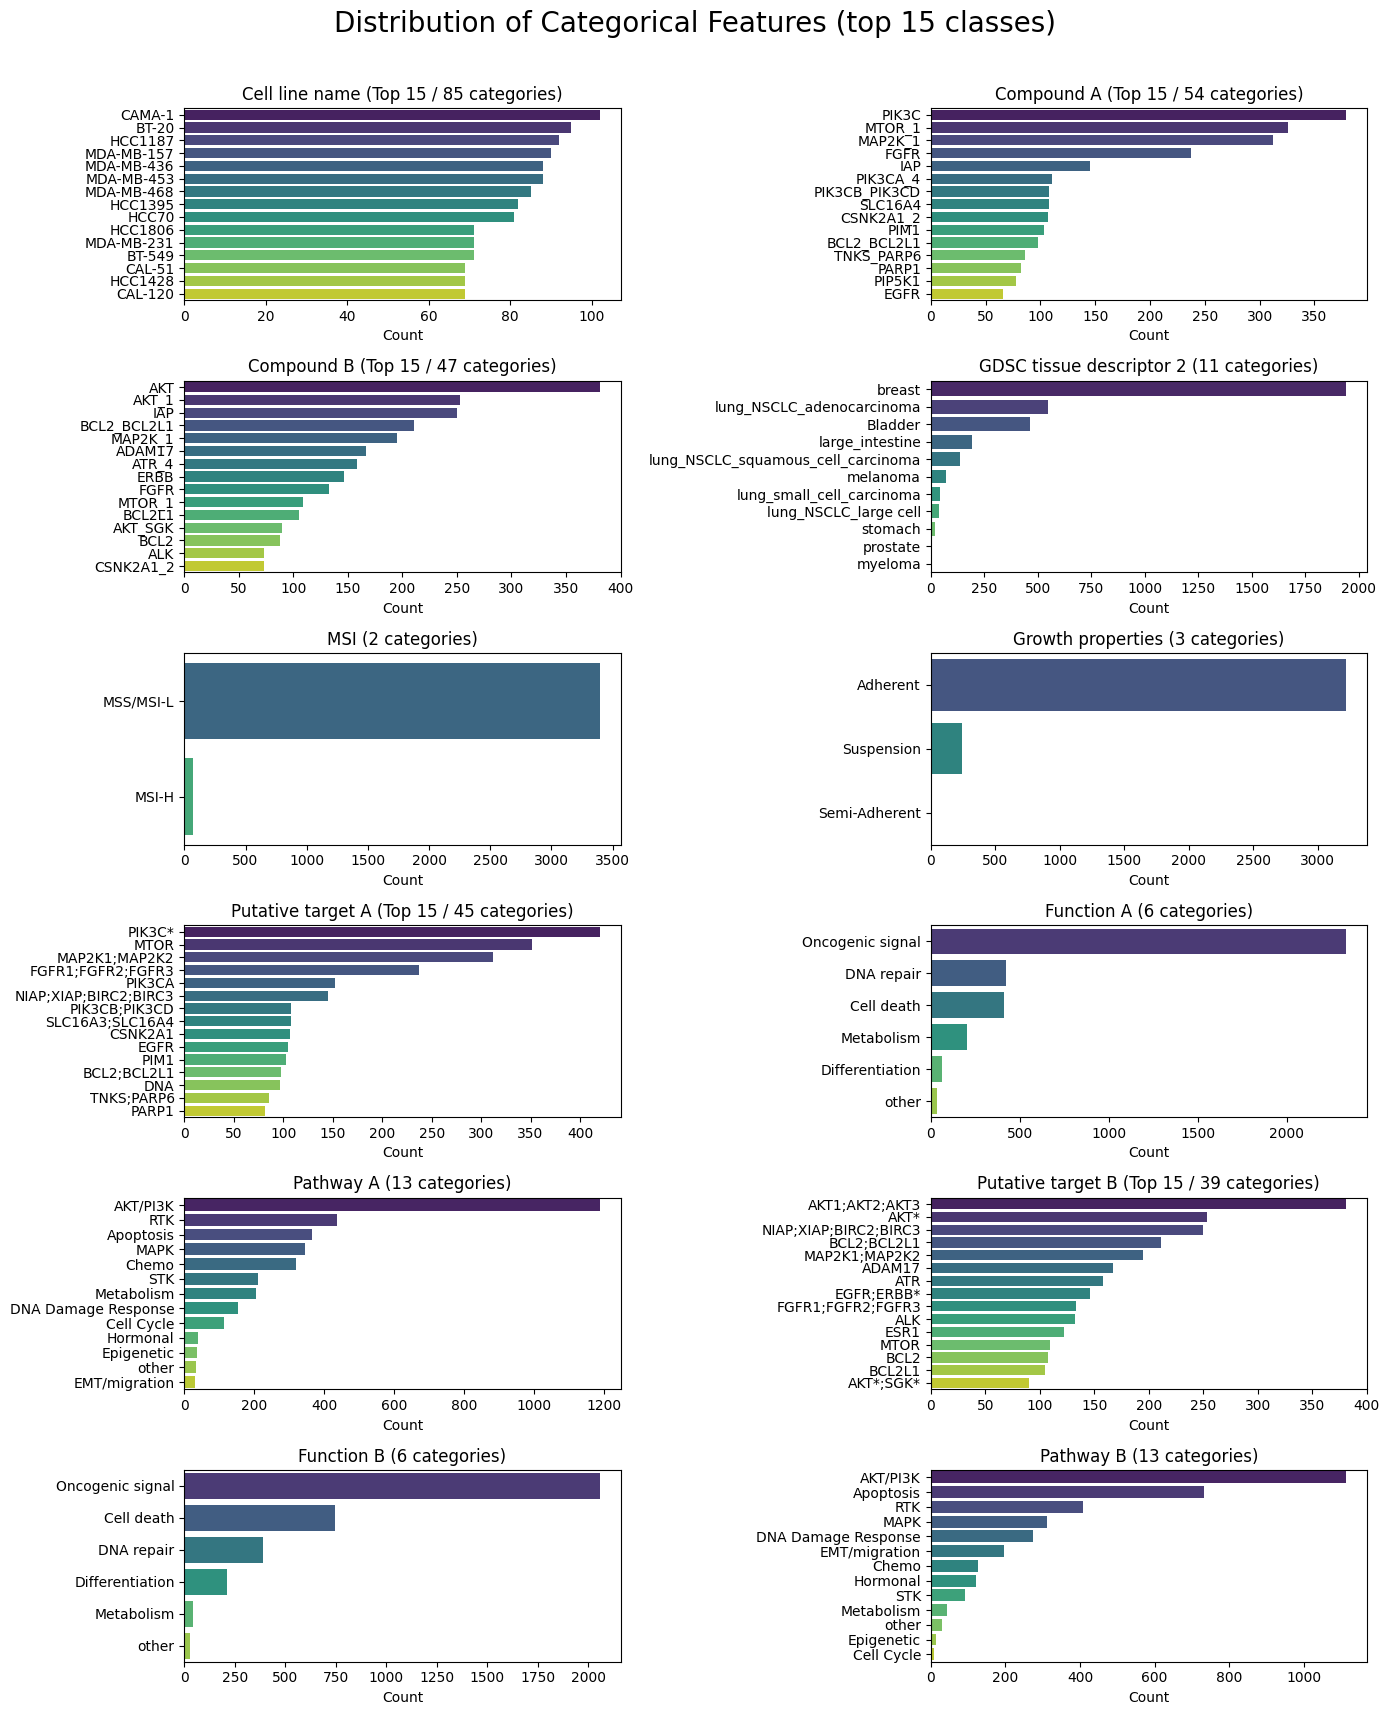

In [328]:
#cat vars distribs
fig, axes = plt.subplots(6, 2, figsize=(14, 18))
axes = axes.flatten()

# choose 15 most repeated classes of each var
for i, col in enumerate(catdf): # for each var
    counts = catdf[col].value_counts() # counts how many times each class and sorts decreasingly
    
    if len(counts) > 15: # if var withs lots of classes
        top_n = counts.iloc[:15] # take top 15
        plot_data = pd.concat([top_n])
        title_suffix = f"(Top 15 / {len(counts)} categories)"
    else: # else plot everything
        plot_data = counts
        title_suffix = f"({len(counts)} categories)"

    sns.barplot(
        x=plot_data.values, 
        y=plot_data.index, 
        ax=axes[i], 
        hue=plot_data.index,      # Tells Seaborn which variable defines the colors
        palette='viridis', 
        legend=False              # Prevents a messy legend from appearing
    )
    
    axes[i].set_title(f'{col} {title_suffix}')
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("") # Cleans up the y-axis label

#title and space
plt.suptitle('Distribution of Categorical Features (top 15 classes)', fontsize=20)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()


* Variables in general seem to be heavily skewed towards certain classes
* In general most experiments are done in breast cancer
* Most experiments involve drugs targeting oncogenic signal, cell death or DNA repair, which is expected for cancer treatment
* Most instances involve cell line with 'MSS/MSSI-L', which indicate a normal DNA repair machinery. We don't expect particular drug sensitivity in them. We also mostly have 'Adherent growth', which indicates solid tumors.
* We do not see correspondence between 'A/B' related varaibles, which is positive in this case, as this aliviates their individual skwedness

### Drug pairs

One of our main goals is to understand the combined effect of two different drugs via the `Synergy score`. In the following, we build graphs with nodes representing drugs and edges conecting pairs from the dataset, with edge color representing the score of the combination. 

As we perform the same drug combinations in several cell lines, we aggregate the score over all cases:

In [329]:
#aggregate synergy score for each pair, over all other vars ---------------------------------------
agg_catdf = df.groupby(['Compound A', 'Compound B'])['Synergy score'].agg(['mean']).reset_index()

#create graph object ------------------------------------------------------------------------------
G = nx.Graph()

#add edges
for _, row in agg_catdf.iterrows(): #iterrows() iterates over rows as index, series
    G.add_edge(row['Compound A'], #in the form (a,b,weight)
               row['Compound B'], 
               weight=row['mean'])

pos = nx.spring_layout(G, k=0.5, seed=42) #layout

#extract edges and scores as separate list
edges = G.edges(data=True)
scores = np.array([edge[2]['weight'] for edge in edges])

#some scores are very high, select cap for clarity -------------------------------------------------
v_limit = 30 
clipped_count = np.sum(np.abs(scores) > v_limit)

#def color palette ----------------------------------------------------------------------------------
custom_colors = ['#762a83', '#bababa', '#1b7837'] 
cmap = mcolors.LinearSegmentedColormap.from_list("PrGn", custom_colors)

norm = mcolors.TwoSlopeNorm(vmin=-v_limit, vcenter=0, vmax=v_limit) #normalize remaining edges
edge_colors = [cmap(norm(np.clip(s, -v_limit, v_limit))) for s in scores]


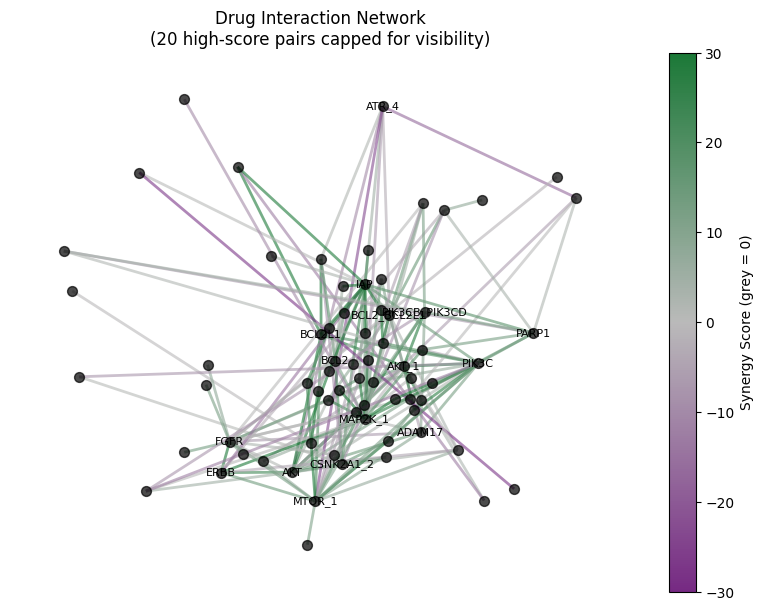

In [330]:
plt.figure(figsize=(10, 7))

#draw nodes
nx.draw_networkx_nodes(G, pos, node_size=50, node_color='black', alpha=0.7)

#draw edges
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=2, alpha=0.6)

#draw labels
d = dict(G.degree)
labels = {node: node for node, degree in d.items() if degree > 5} 
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)

#draw colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, label=f'Synergy Score (grey = 0)', ax=plt.gca())

#title
plt.title(f"Drug Interaction Network\n({clipped_count} high-score pairs capped for visibility)")
plt.savefig('drug_interaction_network.png', dpi=60, bbox_inches='tight')

plt.axis('off')
plt.show()



* Most of our drug pairs have an average synergy score close to zero
* The majority of pairs that interact, enhance each other, rather than antagonize each other
* We have a few hubs, i.e. nodes with more connections, this means some drugs appear more than others in the experiments. They seem to interact synergically with other drugs.

It might be more interesting to go by cell lines. Picking the ones with most experiments:

In [331]:
df['Cell line name'].value_counts().nlargest(12)

Cell line name
CAMA-1        102
BT-20          95
HCC1187        92
MDA-MB-157     90
MDA-MB-436     88
MDA-MB-453     88
MDA-MB-468     85
HCC1395        82
HCC70          81
HCC1806        71
MDA-MB-231     71
BT-549         71
Name: count, dtype: int64

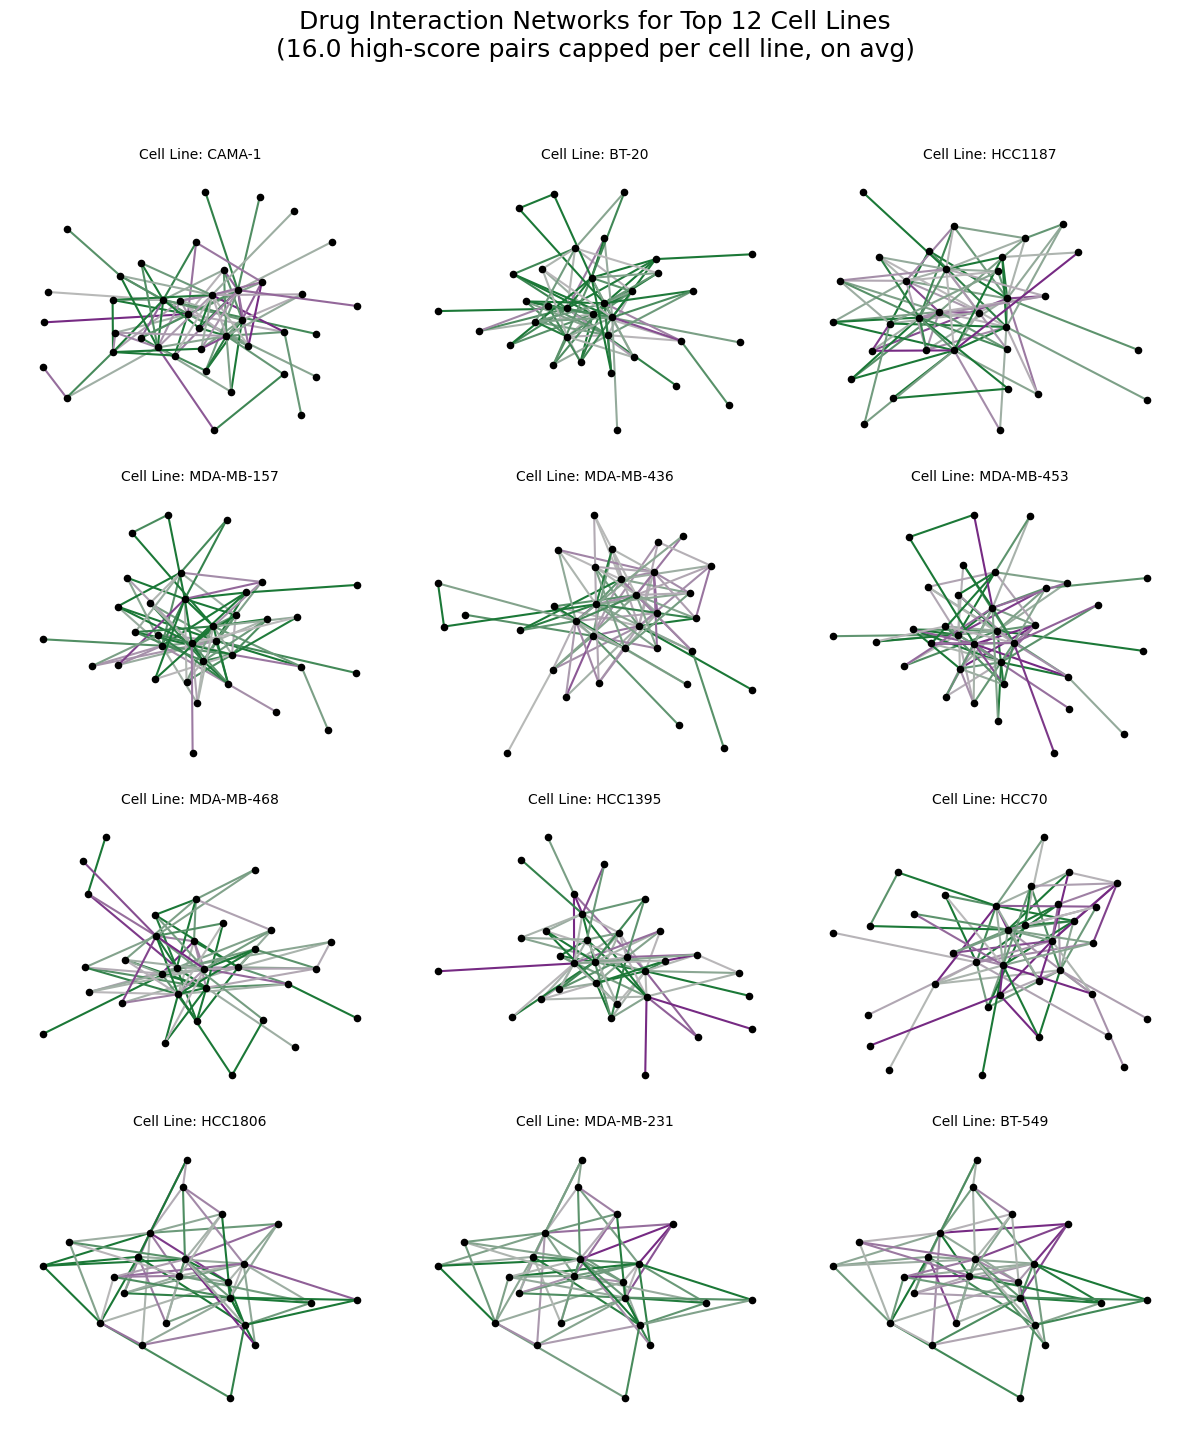

In [332]:
# cell lines with most experiments -----------------------------------------------------------------
top_cell_lines = df['Cell line name'].value_counts().nlargest(12).index 

# some scores are very high, select cap for clarity -------------------------------------------------
v_limit = 30 
total_sub_clipped = 0  #edges above thresh to remove

# plot ---------------------------------------------------------------------------------------------- 
fig, axes = plt.subplots(4, 3, figsize=(12, 14))
axes = axes.flatten()

for i, cell_line in enumerate(top_cell_lines):

    # aggregate cell line df
    sub_df = df[df['Cell line name'] == cell_line]
    sub_df = sub_df.groupby(['Compound A', 'Compound B'])['Synergy score'].agg(['mean']).reset_index()

    # create graph object    
    G_sub = nx.from_pandas_edgelist(sub_df, 'Compound A', 'Compound B', ['mean'])
    pos_sub = nx.spring_layout(G_sub, k=0.8, seed=42)

    # some scores are very high, select cap for clarity
    sub_scores = [d['mean'] for u, v, d in G_sub.edges(data=True)]
    total_sub_clipped += np.sum(np.abs(np.array(sub_scores)) > v_limit)
    
    sub_edge_colors = [cmap(norm(np.clip(s, -v_limit, v_limit))) for s in sub_scores]
    
    nx.draw_networkx_nodes(G_sub, pos_sub, node_size=20, node_color='black', ax=axes[i])
    nx.draw_networkx_edges(G_sub, pos_sub, edge_color=sub_edge_colors, width=1.5, ax=axes[i])
    
    axes[i].set_title(f"Cell Line: {cell_line}", fontsize=10)
    axes[i].axis('off')

#average number of capped edges
avg_clipped = total_sub_clipped / 12

# Updated title with the average clipped count
plt.suptitle(f'Drug Interaction Networks for Top 12 Cell Lines\n({avg_clipped:.1f} high-score pairs capped per cell line, on avg)', fontsize=18, y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.98]) 
plt.show()


we can also see which cell lines produce similar graphs:

/Users/jorgeguzman/Documents/Portfolio/drugsynergy/venv/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/jorgeguzman/Documents/Portfolio/drugsynergy/venv/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


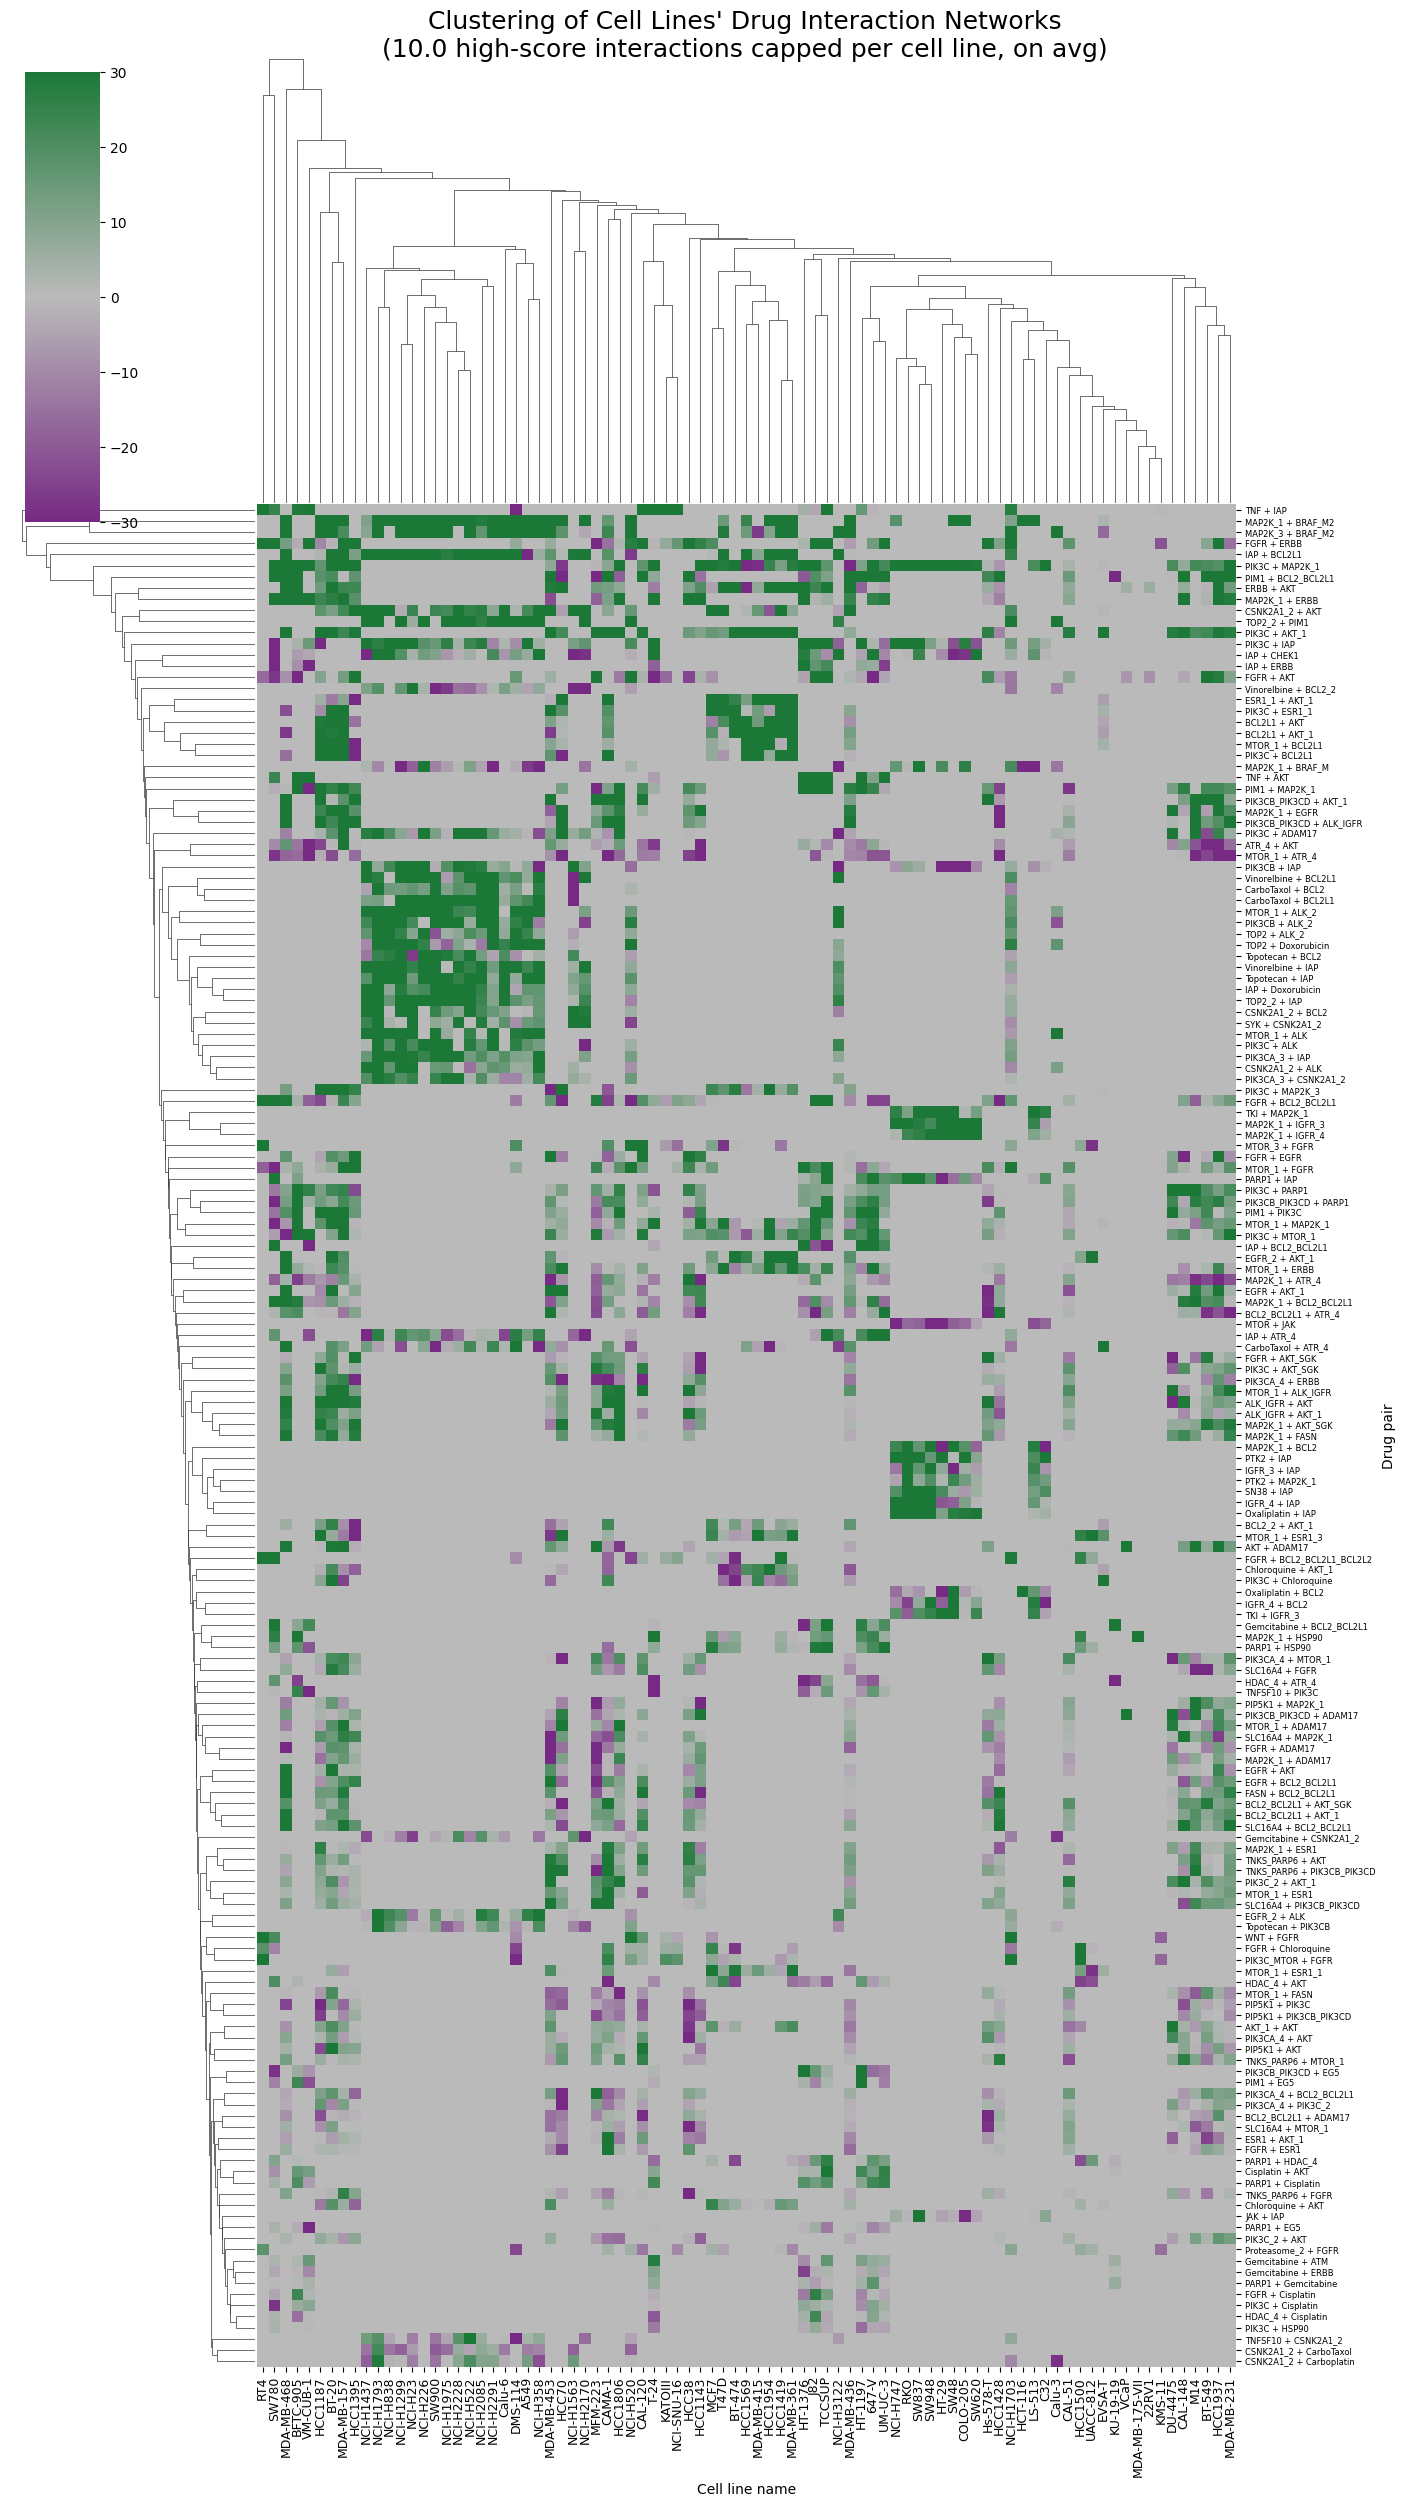

In [333]:
# create matrix ---------------------------------------------------------------------
cluster_df = copy.deepcopy(df)
cluster_df['Drug pair'] = df['Compound A'] + " + " + df['Compound B'] 

# pivot: rows=pairs, cols=cell lines
matrix = cluster_df.pivot_table(index='Drug pair', columns='Cell line name', values='Synergy score').fillna(0)

# some scores are very high, select cap for clarity ---------------------------------
v_limit = 30 
num_capped = (np.abs(matrix.values) > v_limit).sum()

#average number of capped edges
num_cell_lines = matrix.shape[1]
avg_capped_per_line = num_capped / num_cell_lines

# plot ------------------------------------------------------------------------------- 
g = sns.clustermap(
    matrix, 
    cmap=cmap, # uses the custom Purple-Grey-Green palette from your previous block        
    center=0, 
    vmin=-v_limit, 
    vmax=v_limit,
    xticklabels=True, 
    yticklabels=True, 
    figsize=(15, 25)
)

#font
plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=9, rotation=90)
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=6)

#title
g.fig.suptitle(
    f"Clustering of Cell Lines' Drug Interaction Networks\n"
    f"({avg_capped_per_line:.1f} high-score interactions capped per cell line, on avg)", 
    y=1.005, 
    fontsize=18
)

plt.show()


we do notice a few cell lines clustering together, e.g. the `NCI`,`HCC1`,`SW` groups. This makes sense, as numbers following the name denote variations from a wild type. However, we should recall that cell lines in general don't have the same experiments, so it's difficult to conclude that they react similarly to the drug combinations.

### Synergy score distribution among categorical variables

In [334]:
catdf.nunique()

Cell line name              85
Compound A                  54
Compound B                  47
GDSC tissue descriptor 2    11
MSI                          2
Growth properties            3
Putative target A           45
Function A                   6
Pathway A                   13
Putative target B           39
Function B                   6
Pathway B                   13
dtype: int64

It could also be interesting to see how the `Synergy score` aggregates for the different classes of each of the categorical variables:

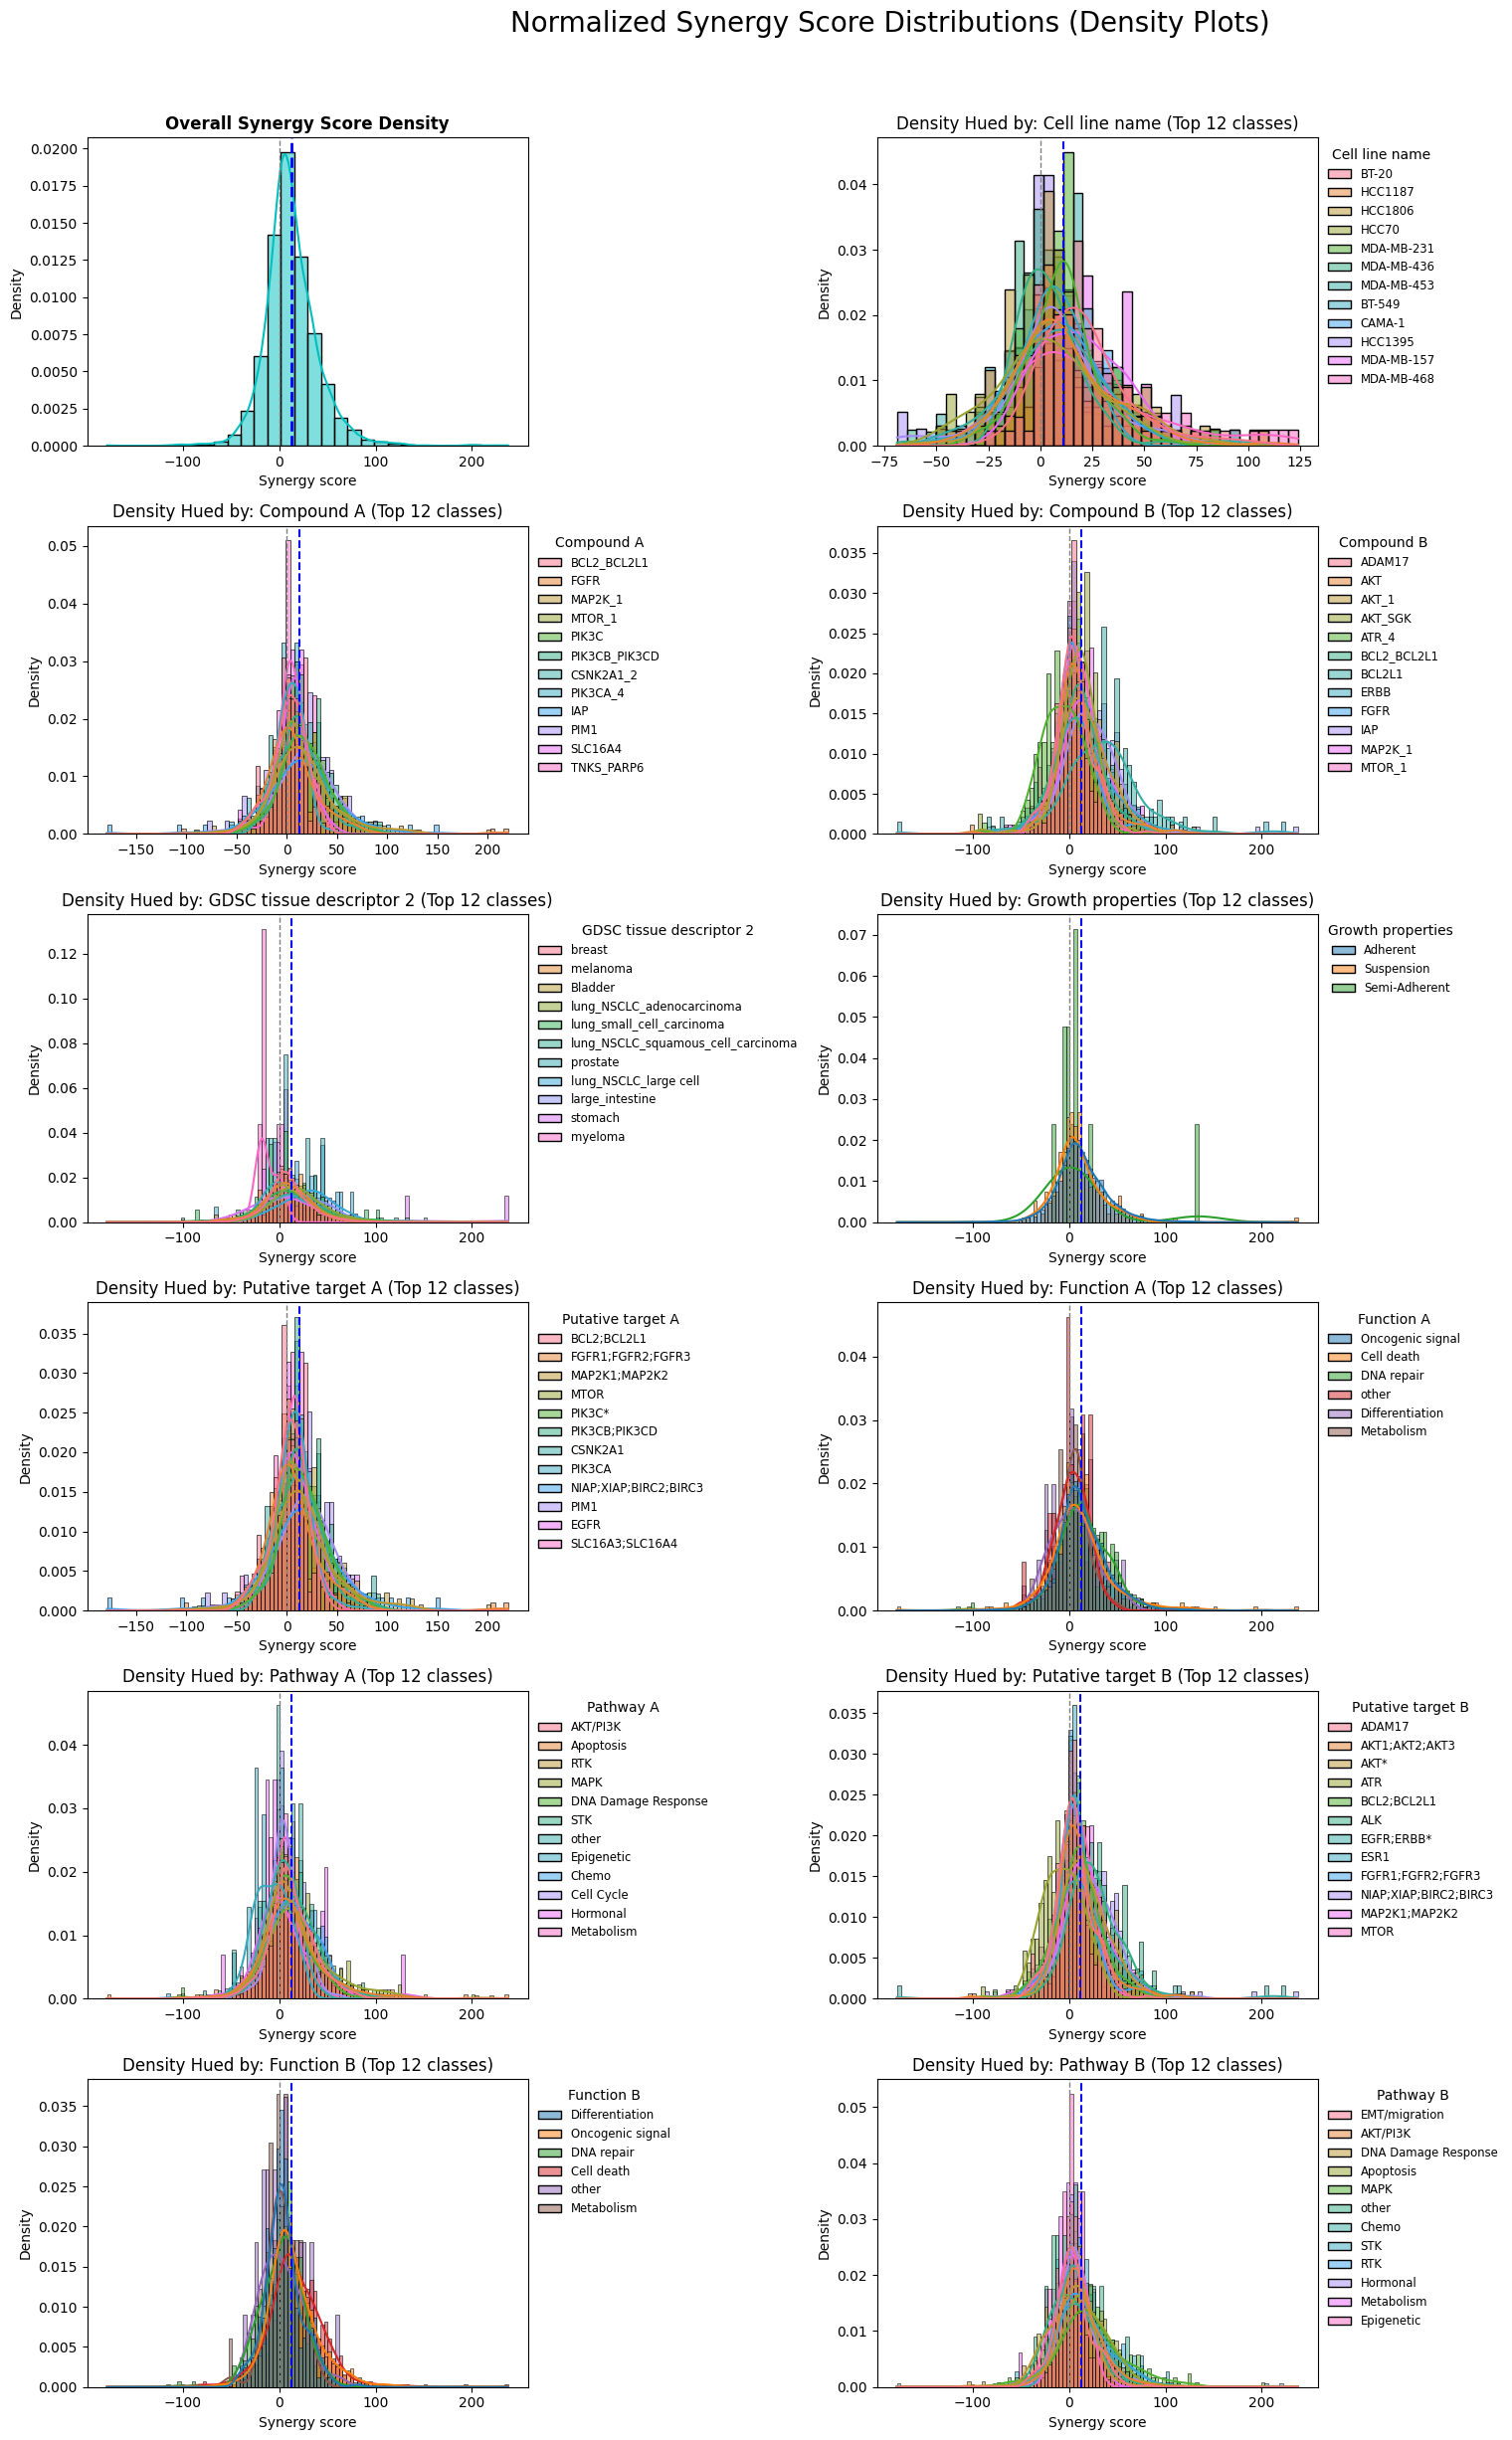

In [335]:
# filter some classes -------------------------------------------------------------------------------
catdf_counts = catdf.nunique()
catvars = catdf_counts[(catdf_counts.values > 2)].index

# figure --------------------------------------------------------------------------------------------
n_vars = len(catvars) + 1
cols = 2
rows = math.ceil(n_vars / cols)

fig, axs = plt.subplots(rows, cols, figsize=(18, rows * 4)) 
axs = axs.flatten()

#plot overall synergy score distribution
sns.histplot(data=df, x='Synergy score', bins=30, kde=True, color='c', ax=axs[0], stat="density")
axs[0].axvline(0, color='gray', linestyle='--', label='Zero (additivity)', linewidth=1) 
axs[0].axvline(df['Synergy score'].mean(), color='blue', label='Overal mean', linestyle='--', linewidth=2)
axs[0].set_title('Overall Synergy Score Density', fontweight='bold')

#plot cat vars
for i, var in enumerate(catvars):
    ax_idx = i + 1 
    
    #only top 12 classes
    top_12_classes = df[var].value_counts().nlargest(12).index
    filtered_data = df[df[var].isin(top_12_classes)]
    
    #normalize each class
    sns.histplot(
        data=filtered_data, 
        x='Synergy score', 
        kde=True, 
        hue=var, 
        ax=axs[ax_idx],
        stat="density",      #normalize by area
        common_norm=False    #each class normalized independently
    )
    
    #vertical lines
    axs[ax_idx].axvline(0, color='gray', linestyle='--', linewidth=1) 
    current_mean = filtered_data['Synergy score'].mean()
    axs[ax_idx].axvline(current_mean, color='blue', linestyle='--', linewidth=1.5)
    
    axs[ax_idx].set_title(f'Density Hued by: {var} (Top 12 classes)')

    #move legend outside
    sns.move_legend(
        axs[ax_idx], "upper left", 
        bbox_to_anchor=(1, 1), 
        fontsize='small', 
        title=var,
        frameon=False
    )

#remove empty subplots
for j in range(n_vars, len(axs)):
    fig.delaxes(axs[j])

plt.suptitle('Normalized Synergy Score Distributions (Density Plots)', fontsize=20, y=1.02)

plt.tight_layout(rect=[0, 0, 0.85, 1]) 
plt.show()


Here we picked classess with $>2$ categoires. We normalized each class independently, keeping the area under the curve at 1, to facilitate comparisons.

* The first thing we notice is that the average synergy score per class remains around the overall average, across all variables. This suggest the experiment design was effectively randomized
    * This is particularly important for the variables `Compound`, `Function`, `Pathway` and `Target`, as it indicates that despite experimental limitations drugs were well paired. A significant deviation from the overall mean would suggest biases, e.g. if experiments involving drugs in the `AKT/PI3k` pathway had particularly high synergy, it could be because they weren't paired with drugs outside of this pathway.
* Some classes seem to present 'shorter', and hence 'fatter' bell curves, indicating a tendency for synergetic or antagonistic interaction However, aside for a couple exceptions, the differences are not very significant

This shows that none of the categorical variables is particularly good at predicting synergy and explains the necessity for a deep learning approach, as the answer seem to lie within complex interactions between the variables